# Pipetting DOE Optimizer

**How to use this notebook:**
1. Run **Cell 1** once to install packages
2. Run **Cell 2** once to load all the code
3. Run **Cell 3** to start a new optimization run
4. Run **Cell 4** to get the next parameters to test
5. Put your images in the folder it tells you, then run **Cell 5** to process them
6. Repeat cells 4 and 5 until the optimizer says DONE
7. Run **Cell 6** to see the best result and convergence plot

---

## Cell 1 — Install packages
Run this once. You can skip it in future sessions if already installed.

In [1]:
%pip install numpy scipy scikit-learn opencv-python matplotlib pandas --quiet

Note: you may need to restart the kernel to use updated packages.


## Cell 2 — Load all the code
Run this once every session. Nothing to edit here.

In [2]:
from __future__ import annotations

import csv
import itertools
import os
import re
import warnings
from dataclasses import dataclass
from datetime import datetime
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.preprocessing import LabelEncoder

# ── Image subtraction config ─────────────────────────────────────────────────
# Tweak these values without touching any other logic

DEFAULT_THRESHOLD = 12
BLUR_KERNEL = 3
ROI_BOTTOM_FRACTION = 0.80
ROI_TOP_FRACTION = 0.25
MIN_CONTOUR_AREA = 8
MAX_ASPECT_RATIO = 3.0
LARGE_BLOB_AREA = 200
DYE_COLOR = "blue"              # Dye colour: "red", "blue", or "green"
                                #   red   → amplifies R-B signal
                                #   blue  → amplifies B-R signal
                                #   green → amplifies G-(R+B)/2 signal
DYE_WEIGHT = 0.80
GRAY_WEIGHT = 0.20
ALIGN_IMAGES = False
# ── Liquid registry ──────────────────────────────────────────────────────────

KNOWN_LIQUIDS = ["water", "glycerol", "ethanol"]

LIQUID_CONCENTRATION_RULES = {
    "water":    (100.0, 100.0),
    "glycerol": (0.0,   100.0),
    "ethanol":  (0.0,   100.0),
}

def validate_liquid(liquid_type, concentration_pct):
    liquid_type = liquid_type.lower().strip()
    if liquid_type not in KNOWN_LIQUIDS:
        raise ValueError(f"Unknown liquid '{liquid_type}'. Known: {KNOWN_LIQUIDS}")
    lo, hi = LIQUID_CONCENTRATION_RULES[liquid_type]
    if not (lo <= concentration_pct <= hi):
        raise ValueError(f"Concentration {concentration_pct}% out of range [{lo}, {hi}] for {liquid_type}.")
    return liquid_type, concentration_pct

# ── Image subtraction ─────────────────────────────────────────────────────────

def align_images(img1: np.ndarray, img2: np.ndarray) -> np.ndarray:
    """
    Align img2 to img1 using ECC (Enhanced Correlation Coefficient) to correct
    residual sub-pixel translation between frames.

    Returns img2 warped to match img1, or the original img2 if alignment fails.
    Only estimates translation (warp_mode=MOTION_TRANSLATION) — appropriate for
    a stable camera with tiny positional drift.
    """
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY).astype(np.float32)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY).astype(np.float32)

    warp_matrix = np.eye(2, 3, dtype=np.float32)
    criteria = (
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
        50,
        1e-4,
    )

    try:
        _, warp_matrix = cv2.findTransformECC(
            gray1, gray2, warp_matrix,
            cv2.MOTION_TRANSLATION, criteria,
        )
        h, w = img1.shape[:2]
        aligned = cv2.warpAffine(
            img2, warp_matrix, (w, h),
            flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP,
        )
        return aligned
    except cv2.error:
        return img2


def build_diff_image(img1: np.ndarray, img2: np.ndarray) -> np.ndarray:
    """
    Build a sensitivity-enhanced diff biased toward the configured dye colour.

    Strategy
    --------
    * Compute a dye-specific opponent-channel signal that is strongly positive
      where the dye is present and near zero for neutral/transparent backgrounds.
    * Blend with a standard grayscale diff (GRAY_WEIGHT) to retain some
      sensitivity to colourless liquid residue.

    Dye channel logic (OpenCV stores channels as B=0, G=1, R=2)
    -----------------------------------------------------------
      red   → R - B   (high for red, low for blue/neutral)
      blue  → B - R   (high for blue, low for red/neutral)
      green → G - (R+B)/2  (high for green, low for red/blue/neutral)
    """
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    gray_diff = cv2.absdiff(gray1, gray2).astype(np.float32)

    f1 = img1.astype(np.float32)
    f2 = img2.astype(np.float32)

    dye = DYE_COLOR.lower()
    if dye == "red":
        signal1 = f1[:, :, 2] - f1[:, :, 0]   # R - B
        signal2 = f2[:, :, 2] - f2[:, :, 0]
    elif dye == "blue":
        signal1 = f1[:, :, 0] - f1[:, :, 2]   # B - R
        signal2 = f2[:, :, 0] - f2[:, :, 2]
    elif dye == "green":
        signal1 = f1[:, :, 1] - (f1[:, :, 2] + f1[:, :, 0]) / 2   # G - (R+B)/2
        signal2 = f2[:, :, 1] - (f2[:, :, 2] + f2[:, :, 0]) / 2
    else:
        raise ValueError(f"Unknown DYE_COLOR '{DYE_COLOR}'. Choose 'red', 'blue', or 'green'.")

    dye_diff = np.abs(signal1 - signal2)

    combined = DYE_WEIGHT * dye_diff + GRAY_WEIGHT * gray_diff
    return np.clip(combined, 0, 255).astype(np.uint8)


def _filter_contours(mask: np.ndarray) -> np.ndarray:
    """
    Keep only contours that look like real liquid changes.

    Rules
    -----
    * Area < MIN_CONTOUR_AREA → always rejected (noise speck).
    * Area >= LARGE_BLOB_AREA → always kept regardless of shape.
      A full liquid column is tall and narrow by nature — we must not
      reject it on aspect ratio grounds.
    * Otherwise: reject if aspect ratio (h/w) > MAX_ASPECT_RATIO.
      Small blobs that are very streaky are shaft-edge artifacts.
    """
    filtered = np.zeros_like(mask)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < MIN_CONTOUR_AREA:
            continue

        if area >= LARGE_BLOB_AREA:
            cv2.drawContours(filtered, [cnt], -1, 255, thickness=cv2.FILLED)
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = h / max(w, 1)
        if aspect_ratio > MAX_ASPECT_RATIO:
            continue

        cv2.drawContours(filtered, [cnt], -1, 255, thickness=cv2.FILLED)

    return filtered


def subtract_images(img1: np.ndarray, img2: np.ndarray,
                    threshold: int = DEFAULT_THRESHOLD) -> Tuple[np.ndarray, np.ndarray, int]:
    """
    Subtract two images and return (diff, mask, changed_pixel_count).

    Pipeline
    --------
    0. ECC alignment  — corrects residual sub-pixel translation (optional, ALIGN_IMAGES).
    1. Dye-biased diff — amplifies configured dye colour, suppresses transparent-edge noise.
    2. Gaussian blur   — small (3px) to smooth sub-pixel noise without losing droplet detail.
    3. Threshold       — low threshold safe due to targeted dye-channel signal.
    4. ROI band mask   — keeps rows between ROI_TOP_FRACTION and ROI_BOTTOM_FRACTION,
                         covering the full tip body while excluding the robot arm above.
    5. Morphology      — open then close to clean up salt-and-pepper noise.
    6. Shape filter    — rejects blobs that are too small or unreasonably elongated.
    """
    if img1 is None or img2 is None:
        raise ValueError("One or both images could not be loaded.")
    if img1.shape != img2.shape:
        raise ValueError(f"Image shapes do not match: {img1.shape} vs {img2.shape}")

    h, w = img1.shape[:2]

    if ALIGN_IMAGES:
        img2 = align_images(img1, img2)

    diff    = build_diff_image(img1, img2)
    blurred = cv2.GaussianBlur(diff, (BLUR_KERNEL, BLUR_KERNEL), 0)
    _, mask = cv2.threshold(blurred, threshold, 255, cv2.THRESH_BINARY)

    roi_top    = int(h * ROI_TOP_FRACTION)
    roi_bottom = int(h * ROI_BOTTOM_FRACTION)
    roi_mask = np.zeros_like(mask)
    roi_mask[roi_top:roi_bottom, :] = 255
    mask = cv2.bitwise_and(mask, roi_mask)

    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = _filter_contours(mask)

    return diff, mask, int(np.count_nonzero(mask))


# ── File parsing ──────────────────────────────────────────────────────────────

def parse_filename(filename):
    name, _ = os.path.splitext(filename)
    m = re.match(r"^(\d{8})_(\d{6})_(\d+?)_(.+)$", name)
    if not m:
        return None
    date_str, time_str, micro_str, remainder = m.groups()
    try:
        ts = datetime.strptime(date_str + time_str, "%Y%m%d%H%M%S")
        ts = ts.replace(microsecond=int(micro_str[:6].ljust(6, "0")))
    except ValueError:
        return None
    col_m = re.search(r"_col_([A-Za-z]\d+)", remainder)
    if not col_m:
        return None
    event_map = {
        "pick_up_tip_col_":     "pick_up_tip",
        "before_aspirate_col_": "before_aspirate",
        "after_aspirate_col_":  "after_aspirate",
        "before_dispense_col_": "before_dispense",
        "after_dispense_col_":  "after_dispense",
    }
    event = next((v for k, v in event_map.items() if remainder.startswith(k)), None)
    if event is None:
        return None
    return {"filename": filename, "timestamp": ts, "column": col_m.group(1), "event": event}

def find_nearest_later(baseline, candidates):
    later = [c for c in candidates if c["timestamp"] >= baseline["timestamp"]]
    return min(later, key=lambda c: (c["timestamp"] - baseline["timestamp"]).total_seconds()) if later else None

# Maximum expected changed-pixel count for a fully-failed dispense.
# Tune this to the typical worst-case value you observe in your images.
MAX_RESIDUAL_PIXELS = 5000

def compute_dispense_score(px_after_dispense):
    """
    Score how cleanly the liquid was dispensed.
    px_after_dispense is already the pixel difference between pick_up_tip
    (baseline/reference) and after_dispense, so fewer pixels = better.
    Score 100 = no residual detected; score 0 = MAX_RESIDUAL_PIXELS or more changed.
    Adjust MAX_RESIDUAL_PIXELS at the top of this section to match your setup.
    """
    fraction = px_after_dispense / MAX_RESIDUAL_PIXELS
    return float(100.0 * (1.0 - np.clip(fraction, 0.0, 1.0)))

def save_overlay(reference_img, mask, output_path):
    overlay = reference_img.copy()
    tint    = reference_img.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        if cv2.contourArea(cnt) < MIN_CONTOUR_AREA:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.drawContours(tint, [cnt], -1, (0, 0, 200), thickness=cv2.FILLED)
        cv2.rectangle(overlay, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.addWeighted(tint, 0.35, overlay, 0.65, 0, overlay)
    cv2.imwrite(output_path, overlay)

def measure_from_images(input_dir, output_dir, threshold=DEFAULT_THRESHOLD, save_visuals=True):
    os.makedirs(output_dir, exist_ok=True)
    for sub in ("diffs", "masks", "overlays"):
        os.makedirs(os.path.join(output_dir, sub), exist_ok=True)

    all_files = [f for f in os.listdir(input_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    parsed = []
    for f in all_files:
        p = parse_filename(f)
        if p:
            parsed.append(p)
        else:
            print(f"  [SKIP] {f}")

    by_col = {}
    for item in parsed:
        by_col.setdefault(item["column"], []).append(item)

    column_results = {}
    csv_rows = []

    for column, items in by_col.items():
        items.sort(key=lambda x: x["timestamp"])
        pickups = [x for x in items if x["event"] == "pick_up_tip"]
        if not pickups:
            print(f"  [WARN] No pick_up_tip for column {column}")
            continue

        for pickup in pickups:
            pickup_img = cv2.imread(os.path.join(input_dir, pickup["filename"]))
            if pickup_img is None:
                continue
            px = {}

            # ── Compare pick_up_tip vs after_dispense only ────────────────
            candidates = [x for x in items if x["event"] == "after_dispense"]
            match = find_nearest_later(pickup, candidates)
            if match is None:
                print(f"  [WARN] No after_dispense found after {pickup['filename']}")
                px["after_dispense"] = None
            else:
                target_img = cv2.imread(os.path.join(input_dir, match["filename"]))
                if target_img is None:
                    px["after_dispense"] = None
                else:
                    diff, mask, n_px = subtract_images(pickup_img, target_img, threshold)
                    px["after_dispense"] = n_px
                    print(f"  {column} pick_up_tip vs after_dispense: {n_px} px")
                    if save_visuals:
                        lbl = (f"{column}_{pickup['timestamp'].strftime('%Y%m%d_%H%M%S_%f')}"
                               f"_vs_after_dispense_{match['timestamp'].strftime('%Y%m%d_%H%M%S_%f')}")
                        cv2.imwrite(os.path.join(output_dir, "diffs",    f"{lbl}_diff.jpg"), diff)
                        cv2.imwrite(os.path.join(output_dir, "masks",    f"{lbl}_mask.jpg"), mask)
                        save_overlay(target_img, mask, os.path.join(output_dir, "overlays", f"{lbl}_overlay.jpg"))
                    csv_rows.append({
                        "column": column, "comparison": "pick_up_tip_vs_after_dispense",
                        "pickup_image": pickup["filename"], "target_image": match["filename"],
                        "pickup_timestamp": pickup["timestamp"].isoformat(),
                        "target_timestamp": match["timestamp"].isoformat(),
                        "time_difference_seconds": (match["timestamp"] - pickup["timestamp"]).total_seconds(),
                        "changed_pixels": n_px,
                    })

            # ── Baseline pixel count for the pick_up_tip image itself ─────
            # Subtract pick_up_tip from itself to get a near-zero noise floor,
            # then record the raw px count alongside after_dispense.
            ad = px.get("after_dispense")
            score = compute_dispense_score(ad) if ad is not None else None
            column_results[column] = {"px_after_dispense": ad, "score": score}

    if csv_rows:
        with open(os.path.join(output_dir, "image_results.csv"), "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(csv_rows[0].keys()))
            writer.writeheader()
            writer.writerows(csv_rows)

    return column_results

def aggregate_score(column_results):
    scores = [v["score"] for v in column_results.values()]
    valid  = [s for s in scores if s is not None]
    if not valid:
        return None
    penalty = (len(scores) - len(valid)) / len(scores) * 20
    return max(0.0, float(np.mean(valid)) - penalty)

# ── Factor definitions ───────────────────────────────────────────────────────

@dataclass
class Factor:
    name:   str
    kind:   str
    low:    float
    high:   float
    levels: Optional[List[float]] = None

PIPETTING_FACTORS = [
    Factor("aspirate_speed", "continuous",  0.0, 31.0),
    Factor("dispense_speed", "continuous",  1.0, 31.0),
    Factor("air_gap",        "categorical", 0.0,  1.0, levels=[0.0, 1.0]),
    Factor("blow_out",       "categorical", 0.0,  1.0, levels=[0.0, 1.0]),
]

# ── Training log ─────────────────────────────────────────────────────────────

TRAINING_CSV = "training_data.csv"

TRAINING_FIELDNAMES = [
    "run_id", "timestamp_utc", "liquid_type", "concentration_pct",
    "iteration", "phase",
    "aspirate_speed", "dispense_speed", "air_gap", "blow_out",
    "accuracy_score", "ei_value", "best_so_far",
    "px_after_dispense",
]

def _init_training_csv(path):
    if not os.path.exists(path):
        with open(path, "w", newline="") as f:
            csv.DictWriter(f, fieldnames=TRAINING_FIELDNAMES).writeheader()

def _append_training_row(path, row):
    with open(path, "a", newline="") as f:
        csv.DictWriter(f, fieldnames=TRAINING_FIELDNAMES, extrasaction="ignore").writerow(row)

# ── Gaussian Process ─────────────────────────────────────────────────────────

def build_gp(X, y):
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(nu=2.5, length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e1))
    )
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5,
                                  normalize_y=True, random_state=42)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gp.fit(X, y)
    return gp

def expected_improvement(X_cands, gp, y_best, xi=0.01):
    mu, sigma = gp.predict(X_cands, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    Z  = (mu - y_best - xi) / sigma
    ei = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma < 1e-9] = 0.0
    return ei

def suggest_next_point(gp, factors, y_best, xi=0.01, n_random=5000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    cont_idx   = [i for i, f in enumerate(factors) if f.kind == "continuous"]
    cat_idx    = [i for i, f in enumerate(factors) if f.kind == "categorical"]
    cat_combos = list(itertools.product(*[factors[i].levels for i in cat_idx]))
    n = len(factors)
    best_pt, best_ei = None, -np.inf
    for combo in cat_combos:
        cands = np.empty((n_random, n))
        for j in cont_idx:
            cands[:, j] = rng.uniform(0.0, 1.0, size=n_random)
        for k, ci in enumerate(cat_idx):
            cands[:, ci] = (combo[k] - factors[ci].low) / (factors[ci].high - factors[ci].low)
        ei_vals = expected_improvement(cands, gp, y_best, xi)
        for idx in np.argsort(ei_vals)[-5:]:
            x0     = cands[idx].copy()
            bounds = [(0.0, 1.0) if j in cont_idx else (x0[j], x0[j]) for j in range(n)]
            def neg_ei(x):
                return -expected_improvement(x.reshape(1, -1), gp, y_best, xi)[0]
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res = minimize(neg_ei, x0, bounds=bounds, method="L-BFGS-B")
            if -res.fun > best_ei:
                best_ei = -res.fun
                best_pt = res.x.copy()
    return best_pt, best_ei

def generate_initial_design(factors, n_points=5, seed=42):
    unit   = LatinHypercube(d=len(factors), seed=seed).random(n=n_points)
    design = np.empty_like(unit)
    for j, f in enumerate(factors):
        scaled = f.low + unit[:, j] * (f.high - f.low)
        if f.kind == "categorical" and f.levels:
            lvls = np.array(f.levels)
            for i in range(n_points):
                design[i, j] = lvls[np.argmin(np.abs(lvls - scaled[i]))]
        else:
            design[:, j] = scaled
    return design

# ── Main optimizer class ─────────────────────────────────────────────────────

class PipettingDOEOptimizer:

    def __init__(self, liquid_type="glycerol", concentration_pct=50.0,
                 factors=None, n_initial=5, max_iterations=20, xi=0.01,
                 convergence_tol=1.0, convergence_window=5,
                 image_threshold=DEFAULT_THRESHOLD,
                 run_id=None, training_csv=TRAINING_CSV, random_seed=42):

        self.liquid_type, self.concentration_pct = validate_liquid(liquid_type, concentration_pct)
        self.factors            = factors or PIPETTING_FACTORS
        self.n_initial          = n_initial
        self.max_iterations     = max_iterations
        self.xi                 = xi
        self.convergence_tol    = convergence_tol
        self.convergence_window = convergence_window
        self.image_threshold    = image_threshold
        self.training_csv       = training_csv
        self.rng                = np.random.default_rng(random_seed)
        self.run_id = run_id or (
            f"{liquid_type}_{concentration_pct:.0f}pct_"
            f"{datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"
        )
        self.X_raw        = []
        self.y_observed   = []
        self.ei_values    = []
        self.phases       = []
        self.gp           = None
        self.iteration    = 0
        self.done         = False
        self._stop_reason = None
        self._initial_design = generate_initial_design(self.factors, n_initial, seed=random_seed)
        _init_training_csv(training_csv)

        print(f"\n{'='*65}")
        print(f"  Run ID  : {self.run_id}")
        print(f"  Liquid  : {self.liquid_type} @ {self.concentration_pct:.1f}%")
        print(f"  Factors : {[f.name for f in self.factors]}")
        print(f"  Budget  : {n_initial} initial + up to {max_iterations - n_initial} BO iterations")
        print(f"  Log     : {training_csv}")
        print(f"{'='*65}\n")

    def _normalize(self, X):
        out = np.empty_like(X)
        for j, f in enumerate(self.factors):
            w = f.high - f.low
            out[:, j] = 0.0 if w == 0 else (X[:, j] - f.low) / w
        return out

    def _denormalize(self, X):
        out = np.empty_like(X)
        for j, f in enumerate(self.factors):
            out[:, j] = f.low + X[:, j] * (f.high - f.low)
        return out

    def _to_dict(self, x_raw):
        return {
            f.name: (int(round(x_raw[j])) if f.kind == "categorical" else round(float(x_raw[j]), 2))
            for j, f in enumerate(self.factors)
        }

    def _log(self, params, score, ei, phase, px):
        best = max(self.y_observed)
        ei_s = f"  EI={ei:.4f}" if ei is not None else ""
        print(f"  [Iter {self.iteration:03d} | {phase:8s}] "
              f"{' '.join(f'{k}={v}' for k,v in params.items())}  "
              f"score={score:.2f}  best={best:.2f}{ei_s}")
        _append_training_row(self.training_csv, {
            "run_id": self.run_id, "timestamp_utc": datetime.utcnow().isoformat(),
            "liquid_type": self.liquid_type, "concentration_pct": self.concentration_pct,
            "iteration": self.iteration, "phase": phase,
            **params,
            "accuracy_score": round(score, 4),
            "ei_value": round(ei, 6) if ei is not None else "",
            "best_so_far": round(best, 4),
            "px_after_dispense":  px.get("after_dispense", ""),
        })

    def suggest(self):
        if self.iteration < self.n_initial:
            return self._to_dict(self._initial_design[self.iteration]), None
        X_norm = self._normalize(np.array(self.X_raw))
        y      = np.array(self.y_observed)
        self.gp = build_gp(X_norm, y)
        next_norm, ei_val = suggest_next_point(self.gp, self.factors, y.max(), self.xi, rng=self.rng)
        next_raw = self._denormalize(next_norm.reshape(1, -1))[0]
        for j, f in enumerate(self.factors):
            if f.kind == "categorical" and f.levels:
                lvls = np.array(f.levels)
                next_raw[j] = lvls[np.argmin(np.abs(lvls - next_raw[j]))]
        return self._to_dict(next_raw), ei_val

    def tell(self, params, score, ei, px=None):
        phase = "INITIAL" if self.iteration < self.n_initial else "BO"
        self.X_raw.append(np.array([params[f.name] for f in self.factors], dtype=float))
        self.y_observed.append(score)
        self.ei_values.append(ei)
        self.phases.append(phase)
        self._log(params, score, ei, phase, px or {})
        self.iteration += 1
        self._check_done()

    def measure_and_tell(self, image_dir, output_dir, params, ei):
        print(f"\n  [Measuring] {image_dir}")
        col_results = measure_from_images(image_dir, output_dir, threshold=self.image_threshold)
        score = aggregate_score(col_results)
        if score is None:
            print("  [ERROR] Could not compute score — check image filenames.")
            return None
        px = {}
        vals = [v["px_after_dispense"] for v in col_results.values() if v.get("px_after_dispense") is not None]
        px["after_dispense"] = int(np.mean(vals)) if vals else None
        self.tell(params, score, ei, px=px)
        return score

    def _check_done(self):
        if self.iteration >= self.max_iterations:
            self._stop_reason = f"Experiment cap: {self.max_iterations} total experiments."
            self.done = True
            return
        bo_idx = [i for i, p in enumerate(self.phases) if p == "BO"]
        if len(bo_idx) >= self.convergence_window:
            older = bo_idx[:-self.convergence_window]
            if older:
                improvement = max(self.y_observed) - max(self.y_observed[i] for i in older)
                if improvement < self.convergence_tol:
                    self._stop_reason = (
                        f"Converged: improvement {improvement:.2f} < "
                        f"{self.convergence_tol} over last {self.convergence_window} BO iters.")
                    self.done = True

    def get_best(self):
        idx = int(np.argmax(self.y_observed))
        return self._to_dict(self.X_raw[idx]), self.y_observed[idx]

    def summary(self):
        best_params, best_score = self.get_best()
        print(f"\n{'='*65}")
        print(f"  DONE  — {self.liquid_type} @ {self.concentration_pct:.1f}%")
        print(f"  Iterations  : {self.iteration}")
        print(f"  Stop reason : {self._stop_reason}")
        print(f"  Best score  : {best_score:.2f}/100")
        print(f"  Best params : {best_params}")
        print(f"  Training log: {self.training_csv}")
        print(f"{'='*65}\n")

    def plot_convergence(self, save_path=None):
        save_path = save_path or f"convergence_{self.run_id}.png"
        iters  = np.arange(len(self.y_observed))
        accs   = np.array(self.y_observed)
        best   = np.maximum.accumulate(accs)
        colors = ["#1f77b4" if p == "INITIAL" else "#ff7f0e" for p in self.phases]
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
        ax1.scatter(iters, accs, c=colors, s=50, zorder=3, edgecolors="k", linewidths=0.5)
        ax1.axvline(x=self.n_initial - 0.5, color="gray", linestyle="--", alpha=0.7)
        ax1.set_ylabel("Accuracy Score")
        ax1.set_title(f"{self.liquid_type.title()} {self.concentration_pct:.0f}% — DOE Convergence")
        from matplotlib.patches import Patch
        ax1.legend(handles=[
            Patch(facecolor="#1f77b4", edgecolor="k", label="Initial (LHS)"),
            Patch(facecolor="#ff7f0e", edgecolor="k", label="Bayesian Opt"),
        ], loc="lower right")
        ax1.grid(True, alpha=0.3)
        ax2.plot(iters, best, "r-o", markersize=4, linewidth=2)
        ax2.axvline(x=self.n_initial - 0.5, color="gray", linestyle="--", alpha=0.7)
        ax2.set_xlabel("Iteration")
        ax2.set_ylabel("Best Score")
        ax2.set_title("Cumulative Best Score")
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        print(f"  Convergence plot saved: {save_path}")
        plt.show()

# ── MetaModel ────────────────────────────────────────────────────────────────

class MetaModel:

    def __init__(self):
        self._models = {}
        self._le = LabelEncoder()
        self._le.classes_ = np.array(KNOWN_LIQUIDS)
        self._trained = False
        self._factor_names = [f.name for f in PIPETTING_FACTORS]

    def fit(self, training_csv=TRAINING_CSV, min_runs=3):
        import pandas as pd
        if not os.path.exists(training_csv):
            print(f"[MetaModel] No training data found at {training_csv}")
            return False
        df = pd.read_csv(training_csv)
        if df.empty:
            print("[MetaModel] Training CSV is empty.")
            return False
        best_per_run = (df.sort_values("accuracy_score", ascending=False)
                          .groupby("run_id", as_index=False).first())
        n = len(best_per_run)
        if n < min_runs:
            print(f"[MetaModel] Only {n} run(s). Need at least {min_runs}. Keep collecting data.")
            return False
        X = np.column_stack([
            self._le.transform(best_per_run["liquid_type"].str.lower()),
            best_per_run["concentration_pct"].values.astype(float),
        ])
        print(f"\n[MetaModel] Fitting on {n} run(s)...")
        for name in self._factor_names:
            if name not in best_per_run.columns:
                continue
            self._models[name] = build_gp(X, best_per_run[name].values.astype(float))
            print(f"  ✓ {name}")
        self._trained = True
        print("[MetaModel] Ready.\n")
        return True

    def predict(self, liquid_type, concentration_pct):
        if not self._trained:
            print("[MetaModel] Not fitted yet. Call fit() first.")
            return None
        liquid_type = liquid_type.lower().strip()
        if liquid_type not in self._le.classes_:
            print(f"[MetaModel] Unknown liquid '{liquid_type}'.")
            return None
        X_new = np.array([[self._le.transform([liquid_type])[0], concentration_pct]])
        print(f"\n[MetaModel] Predicted optimal params for {liquid_type} @ {concentration_pct:.1f}%:")
        predictions = {}
        for name, gp in self._models.items():
            mu, sigma = gp.predict(X_new, return_std=True)
            f = next(fa for fa in PIPETTING_FACTORS if fa.name == name)
            val = float(np.clip(mu[0], f.low, f.high))
            if f.kind == "categorical" and f.levels:
                lvls = np.array(f.levels)
                val = float(lvls[np.argmin(np.abs(lvls - val))])
            predictions[name] = val
            print(f"  {name:20s} = {val:.2f}  (±{sigma[0]:.2f})")
        return predictions

    def coverage_report(self, training_csv=TRAINING_CSV):
        import pandas as pd
        if not os.path.exists(training_csv):
            print("No training data yet.")
            return
        df = pd.read_csv(training_csv)
        print("\n[MetaModel] Training data coverage:")
        summary = (df.groupby(["liquid_type", "concentration_pct"])
                     .agg(n_iters=("iteration", "count"),
                          best_score=("accuracy_score", "max"),
                          n_runs=("run_id", "nunique"))
                     .reset_index())
        print(summary.to_string(index=False))

print("✓ All code loaded successfully.")
print(f"  Image threshold : {DEFAULT_THRESHOLD}")
print(f"  ROI             : top {ROI_TOP_FRACTION*100:.0f}% to {ROI_BOTTOM_FRACTION*100:.0f}% of frame")
print(f"  Dye color       : {DYE_COLOR}  |  Dye weight: {DYE_WEIGHT}  |  Gray weight: {GRAY_WEIGHT}")
print(f"  Align images    : {ALIGN_IMAGES}")

✓ All code loaded successfully.
  Image threshold : 12
  ROI             : top 25% to 80% of frame
  Dye color       : blue  |  Dye weight: 0.8  |  Gray weight: 0.2
  Align images    : False


## Cell 3 — Set up a new run

Edit the two folder paths below to match where your images are.
Then run this cell to create the optimizer.

In [11]:
# ── EDIT THESE TWO PATHS ──────────────────────────────────────────────────────
IMAGE_BASE_DIR  = r"experiments/ethanol"   # subfolders iter_000, iter_001 etc go in here
OUTPUT_BASE_DIR = r"output/ethanol"        # results, masks, overlays saved here
# ─────────────────────────────────────────────────────────────────────────────

opt = PipettingDOEOptimizer(
    liquid_type       = "ethanol", #change this to ethanol, water, or glycerol
    concentration_pct = 100.0,
    n_initial         = 5,
    max_iterations    = 20,
)

current_params = None
current_ei     = None

print("Ready. Run Cell 4 to get your first parameters.")


  Run ID  : ethanol_100pct_20260421_154955
  Liquid  : ethanol @ 100.0%
  Factors : ['aspirate_speed', 'dispense_speed', 'air_gap', 'blow_out']
  Budget  : 5 initial + up to 15 BO iterations
  Log     : training_data.csv

Ready. Run Cell 4 to get your first parameters.


/var/folders/ft/cfj2fhnn1tn_95kdm5qcvxtm0000gn/T/ipykernel_78781/111514719.py:486: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f"{datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"


## Cell 4 — Get next parameters to test

Run this to see what parameters to use for your next experiment.
Save the images to the folder it shows, then run Cell 5.

In [31]:
if opt.done:
    print("Optimization complete. Run Cell 6 to see the best results.")
else:
    current_params, current_ei = opt.suggest()
    phase = "INITIAL" if opt.iteration < opt.n_initial else "BAYESIAN OPT"

    print(f"\n{'='*55}")
    print(f"  Iteration {opt.iteration + 1}  |  Phase: {phase}")
    print(f"{'='*55}")
    print("  Run your experiment with these parameters:\n")
    for k, v in current_params.items():
        print(f"    {k:20s}: {v}")
    image_dir = os.path.join(IMAGE_BASE_DIR, f"iter_{opt.iteration:03d}")
    print(f"\n  Save images to: {os.path.abspath(image_dir)}")
    print(f"{'='*55}")
    print("\nOnce images are saved, run Cell 5.")


  Iteration 5  |  Phase: INITIAL
  Run your experiment with these parameters:

    aspirate_speed      : 21.36
    dispense_speed      : 30.62
    air_gap             : 0
    blow_out            : 0

  Save images to: /Users/anoushkasamuel/VSCode/src/LMABII/project/whatneednow/experiments/ethanol/iter_004

Once images are saved, run Cell 5.


## Cell 5 — Process images and record the score

Run this after saving images to the folder shown above.
Then go back to Cell 4 for the next parameters.

In [32]:
if current_params is None:
    print("Run Cell 4 first to get parameters.")
elif opt.done:
    print("Optimization complete. Run Cell 6 to see the best results.")
else:
    image_dir  = os.path.join(IMAGE_BASE_DIR,  f"iter_{opt.iteration:03d}")
    output_dir = os.path.join(OUTPUT_BASE_DIR, f"iter_{opt.iteration:03d}")

    if not os.path.isdir(image_dir):
        print(f"  [ERROR] Folder not found: {os.path.abspath(image_dir)}")
        print("  Create the folder, add your images, then re-run this cell.")
    else:
        score = opt.measure_and_tell(image_dir, output_dir, current_params, current_ei)
        if score is not None:
            print(f"\n  Score: {score:.1f}/100")
            if opt.done:
                print("\n  Optimization complete! Run Cell 6 to see the best results.")
            else:
                print(f"  Experiments remaining: up to {opt.max_iterations - opt.iteration}")
                print("  Go back to Cell 4 to get the next parameters.")


  [Measuring] experiments/ethanol/iter_004
  [SKIP] 20260421_133906_332848_drop_tip_col_A7.jpg
  [SKIP] 20260421_134332_685959_drop_tip_col_A12.jpg
  [SKIP] 20260421_133627_344166_drop_tip_col_A4.jpg
  [SKIP] 20260421_134052_905614_drop_tip_col_A9.jpg
  [SKIP] 20260421_134239_420359_drop_tip_col_A11.jpg
  [SKIP] 20260421_133441_426621_drop_tip_col_A2.jpg
  [SKIP] 20260421_133720_301181_drop_tip_col_A5.jpg
  [SKIP] 20260421_134145_971271_drop_tip_col_A10.jpg
  [SKIP] 20260421_133348_724452_drop_tip_col_A1.jpg
  [SKIP] 20260421_133813_195351_drop_tip_col_A6.jpg
  [SKIP] 20260421_133959_490678_drop_tip_col_A8.jpg
  [SKIP] 20260421_133534_465056_drop_tip_col_A3.jpg
  A4 pick_up_tip vs after_dispense: 2715 px
  A5 pick_up_tip vs after_dispense: 2436 px
  A10 pick_up_tip vs after_dispense: 1491 px
  A2 pick_up_tip vs after_dispense: 1975 px
  A6 pick_up_tip vs after_dispense: 2689 px
  A8 pick_up_tip vs after_dispense: 1514 px
  A11 pick_up_tip vs after_dispense: 1649 px
  A12 pick_up_tip v

/var/folders/ft/cfj2fhnn1tn_95kdm5qcvxtm0000gn/T/ipykernel_78781/111514719.py:533: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "run_id": self.run_id, "timestamp_utc": datetime.utcnow().isoformat(),


## Cell 6 — Final results and convergence plot
Run when done, or any time to check progress.


  DONE  — ethanol @ 100.0%
  Iterations  : 5
  Stop reason : None
  Best score  : 93.43/100
  Best params : {'aspirate_speed': 11.82, 'dispense_speed': 7.15, 'air_gap': 0, 'blow_out': 1}
  Training log: training_data.csv

  Convergence plot saved: output/ethanol/convergence.png


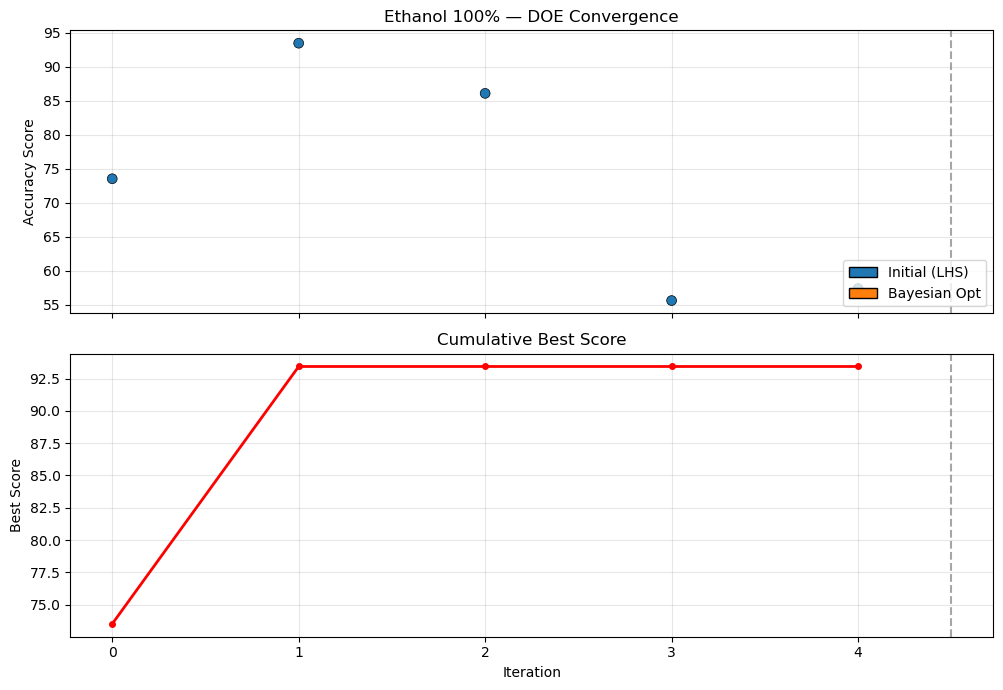

In [33]:
if len(opt.y_observed) == 0:
    print("No results yet. Complete at least one iteration first.")
else:
    opt.summary()
    opt.plot_convergence(save_path=os.path.join(OUTPUT_BASE_DIR, "convergence.png"))

---
## Cell 7 — Check training data coverage (optional)

In [9]:
meta = MetaModel()
meta.coverage_report("training_data.csv")


[MetaModel] Training data coverage:
liquid_type  concentration_pct  n_iters  best_score  n_runs
   glycerol               50.0       21    100.0000       8
      water              100.0        6     99.6029       1


---
## Cell 8 — Predict optimal params for a new liquid (optional)
Only works once you have at least 3 different liquid+concentration runs logged.

In [8]:
meta = MetaModel()
fitted = meta.fit("training_data.csv")

if fitted:
    # ── EDIT THESE ────────────────────────────────
    predict_liquid        = "ethanol"
    predict_concentration = 100.0
    # ──────────────────────────────────────────────
    meta.predict(predict_liquid, predict_concentration)


[MetaModel] Fitting on 9 run(s)...
  ✓ aspirate_speed
  ✓ dispense_speed
  ✓ air_gap
  ✓ blow_out
[MetaModel] Ready.


[MetaModel] Predicted optimal params for ethanol @ 100.0%:
  aspirate_speed       = 9.94  (±12.08)
  dispense_speed       = 17.60  (±1.74)
  air_gap              = 1.00  (±0.00)
  blow_out             = 0.00  (±0.47)
